In [1]:
import os
import re
import sys
import math
import string
from pathlib import Path
from collections import Counter

import datasets

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from pymorphy3 import MorphAnalyzer


sys.path.append(str(Path.cwd().parent))
from src.utils import get_project_root

In [2]:
PROJECT_ROOT = get_project_root()
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts" / "EDA"
RAW_DATA_PATH = PROJECT_ROOT / "data"/ "raw"
PREPROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "preprocessed"
os.makedirs(ARTIFACTS_PATH, exist_ok=True)
os.makedirs(RAW_DATA_PATH, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_PATH, exist_ok=True)

In [3]:
russian_names = {
    0: "Климат", 1: "Конфликты", 2: "Культура",
    3: "Экономика", 4: "Глянец", 5: "Здоровье",
    6: "Политика", 7: "Наука", 8: "Общество",
    9: "Спорт", 10: "Путешествия"
}
classes = sorted(russian_names.keys())

dataset = datasets.load_dataset(
    "data-silence/rus_news_classifier",
    cache_dir=RAW_DATA_PATH
)

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})

Данный датасет уже предразделен на `train`/`test`, однако для собственных эксперемнтов, я соединю их, а затем сделаю собственный сплит, когда буду обучать модели.

In [5]:
df = pd.concat(
    [
        dataset["train"].to_pandas(),
        dataset["test"].to_pandas()
    ], 
    axis=0,
    ignore_index=True
)
df["category_name"] = df["labels"].map(russian_names)

In [6]:
df.head()

,news,labels,category_name
0,Житель Москвы сходил на сеанс эротического мас...,1,Конфликты
1,В 2021 году Microsoft выпустит специальную вер...,7,Наука
2,Министерство культуры и информационной политик...,2,Культура
3,Британский боксер-тяжеловес Тайсон Фьюри оскор...,9,Спорт
4,Растущая напряженность между Индией и Китаем в...,1,Конфликты


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   news           71913 non-null  object
 1   labels         71913 non-null  int32 
 2   category_name  71913 non-null  object
dtypes: int32(1), object(2)
memory usage: 1.4+ MB


In [8]:
df["category_name"].value_counts(normalize=True)

category_name
Глянец         0.139516
Конфликты      0.108464
Экономика      0.096853
Политика       0.096589
Наука          0.094128
Здоровье       0.086479
Общество       0.085409
Спорт          0.083434
Культура       0.079999
Климат         0.065190
Путешествия    0.063938
Name: proportion, dtype: float64

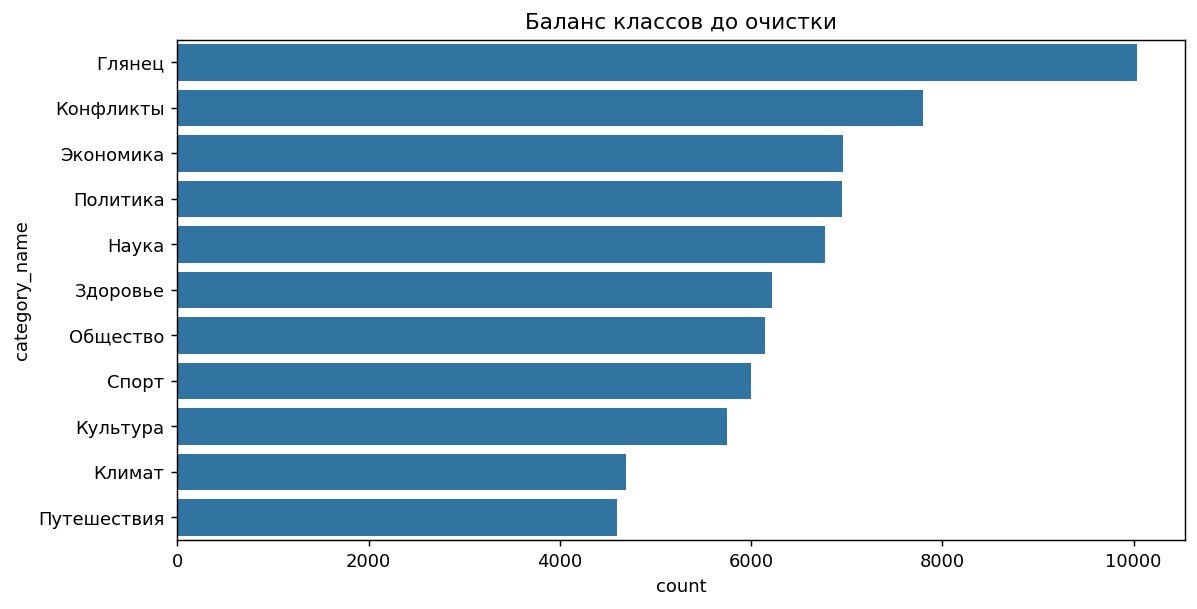

In [9]:
plt.figure(figsize=(10, 5), dpi=130)
plt.title("Баланс классов до очистки")
sns.countplot(
    data=df,
    y="category_name",
    order=df["category_name"].value_counts().index
)
plt.savefig(ARTIFACTS_PATH / "class_balance_before_prerpocessing.png")
plt.show()

В датасете нет пропусков

In [10]:
df.news.duplicated().sum()

np.int64(496)

In [11]:
df = df[~df.news.duplicated()]

Выявлено и удалено 494 дубликатов статей

Создадим дополнительные столбцы в датасете: 
- Категория (расшифровка лейбла)
- Длина текста в символах/словах

Важно учитывать длину статей, т.к. слишком мелкие/крупные статьи могут вредить обучению

In [12]:
df["text_len"] = df["news"].apply(len)
df["words_count"] = df["news"].str.findall(r"\b\w+\b").str.len()

In [13]:
df.head()

,news,labels,category_name,text_len,words_count
0,Житель Москвы сходил на сеанс эротического мас...,1,Конфликты,723,101
1,В 2021 году Microsoft выпустит специальную вер...,7,Наука,1673,232
2,Министерство культуры и информационной политик...,2,Культура,2542,338
3,Британский боксер-тяжеловес Тайсон Фьюри оскор...,9,Спорт,905,130
4,Растущая напряженность между Индией и Китаем в...,1,Конфликты,2067,277


Присутствует дисбаланс классов, однако он не критичный. При обучении важно учитывать этот момент и опираться на метрику `f1`, которая учитывает данный расклад.

Далее проверим размеры статей.

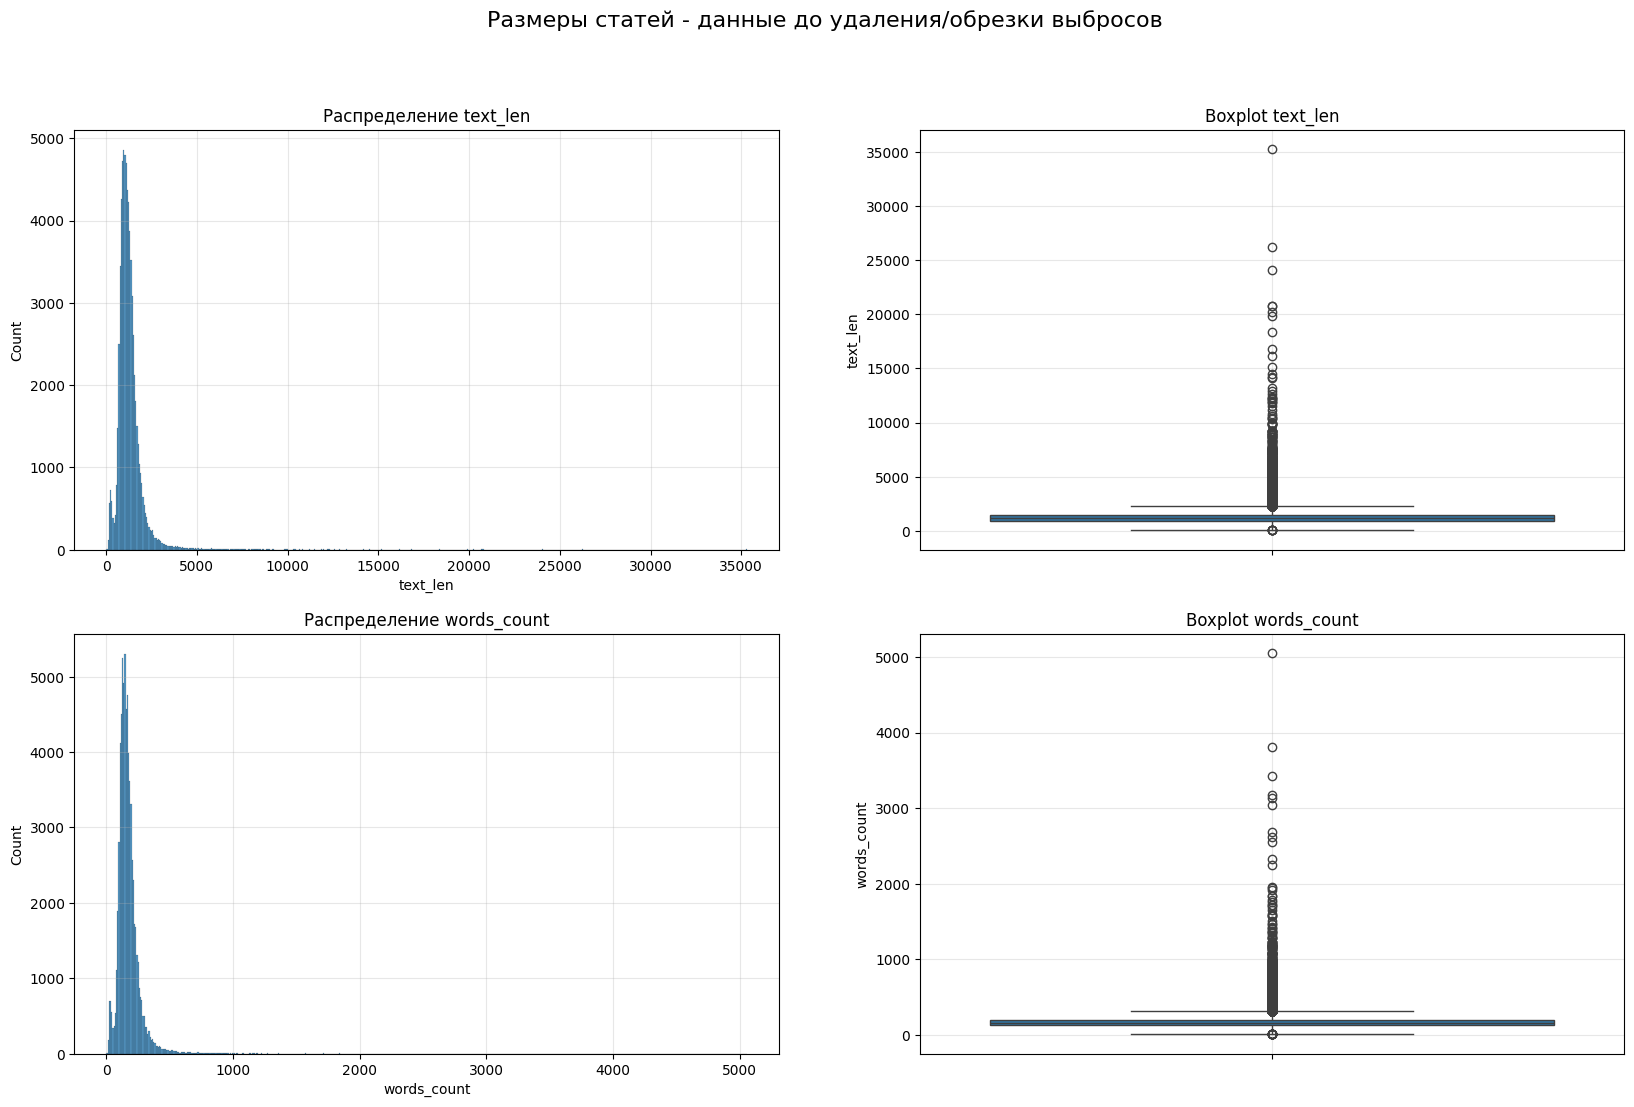

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12), dpi=100)
fig.suptitle("Размеры статей - данные до удаления/обрезки выбросов", fontsize=16)

plt.subplot(2, 2, 1)
sns.histplot(df["text_len"])
plt.title("Распределение text_len")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
sns.boxplot(y=df["text_len"])
plt.title("Boxplot text_len")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
sns.histplot(df["words_count"])
plt.title("Распределение words_count")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
sns.boxplot(y=df["words_count"])
plt.title("Boxplot words_count")
plt.grid(True, alpha=0.3)

plt.savefig(ARTIFACTS_PATH / "news_len_before_outlier_removing.png")
plt.show()

In [15]:
df["words_count"].describe()

count    71417.000000
mean       174.532436
std         98.060053
min          3.000000
25%        126.000000
50%        159.000000
75%        201.000000
max       5057.000000
Name: words_count, dtype: float64

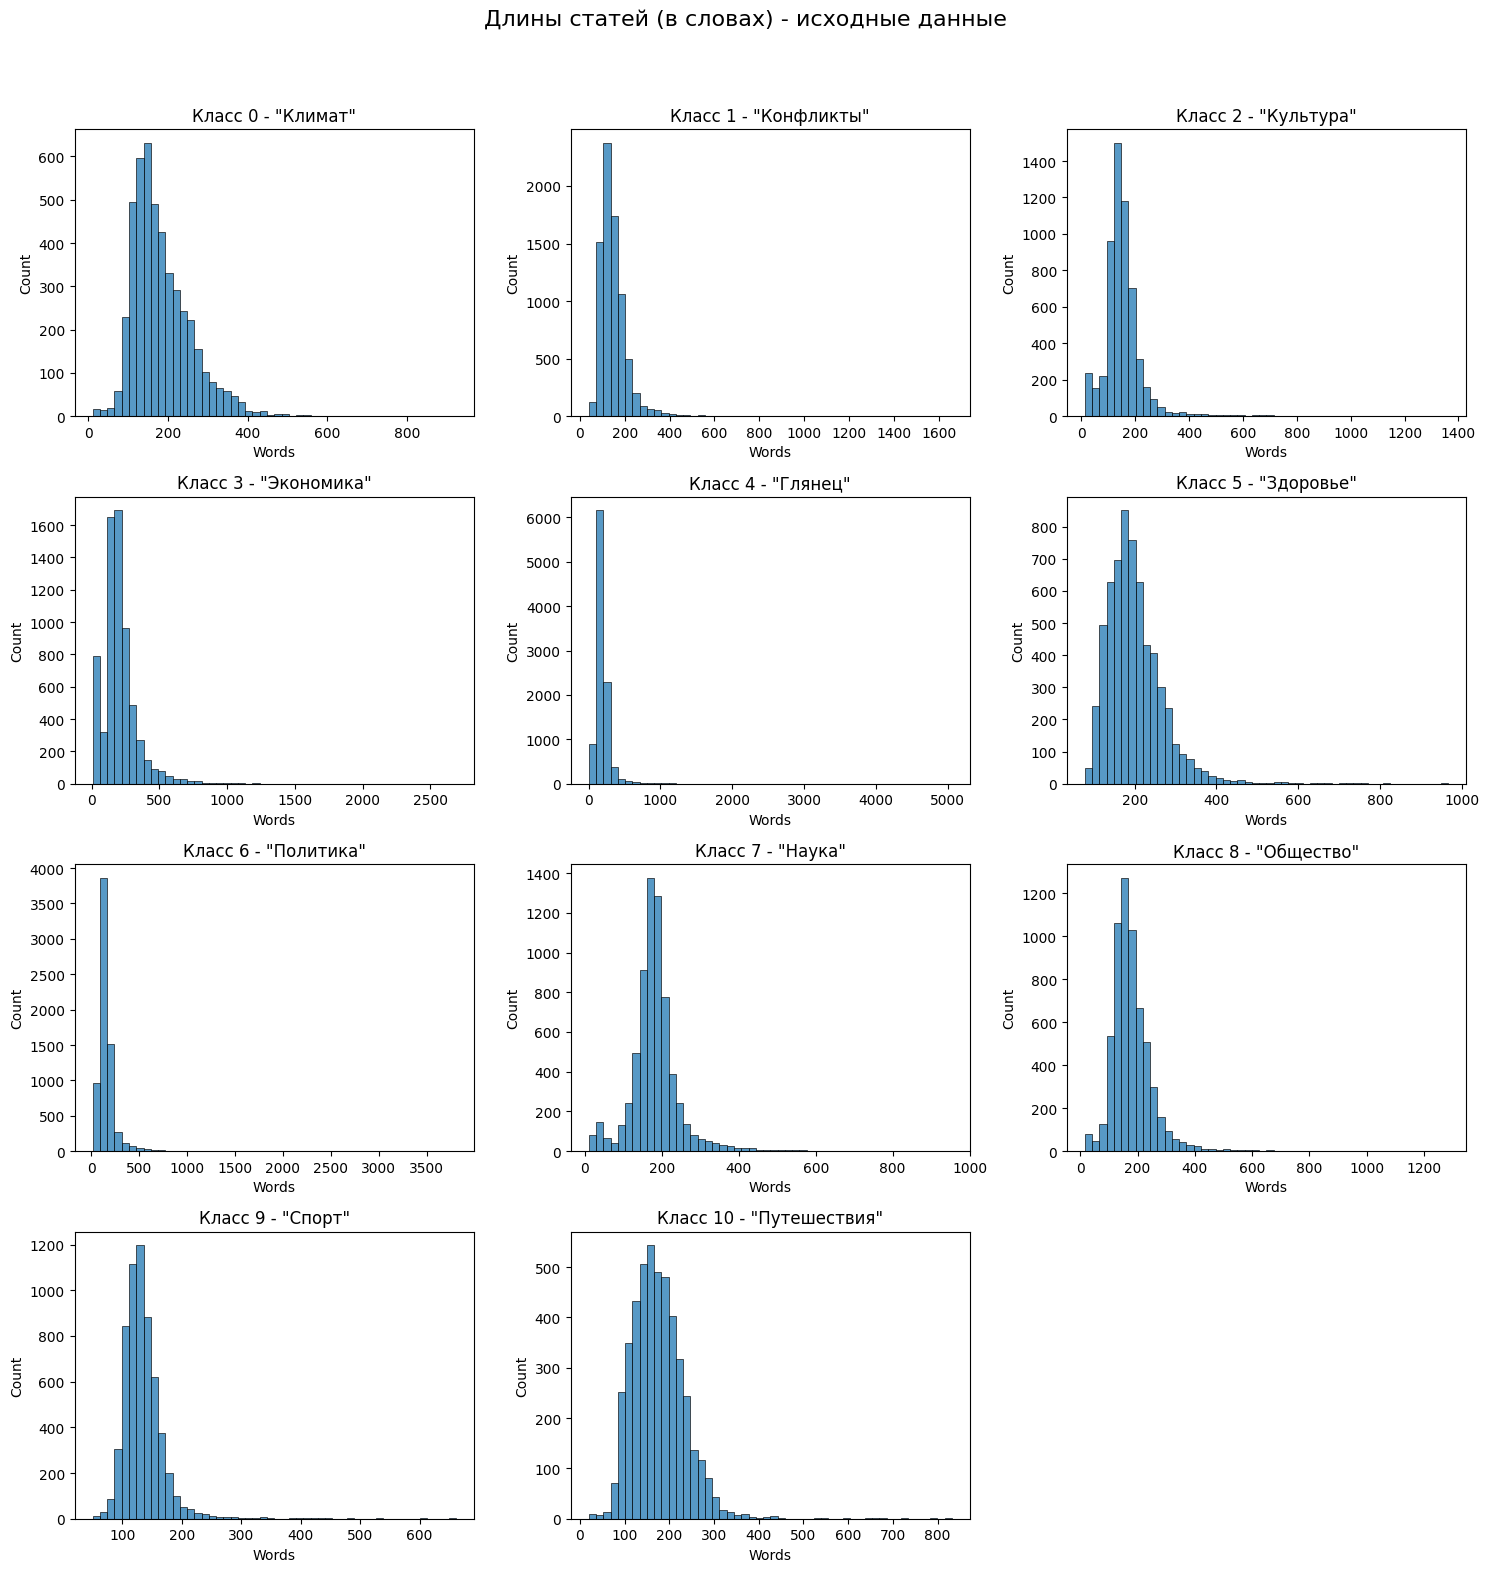

In [16]:
ncols = 3
nrows = math.ceil(len(classes) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle("Длины статей (в словах) - исходные данные", fontsize=16)

axes = axes.flatten()

for ax, cls in zip(axes, classes):
    subset = df[df["labels"] == cls]
    sns.histplot(x=subset["words_count"], ax=ax, bins=50)
    ax.set_title(f"Класс {cls} - \"{russian_names[cls]}\"")
    ax.set_xlabel("Words")

for ax in axes[len(classes):]:
    fig.delaxes(ax)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(ARTIFACTS_PATH / "news_len_by_classes_before_outlier_removing.png")
plt.show()

В датасете наблюдаются тексты с аномально малой и аномально большой длиной, что указывает на наличие выбросов в распределении их длины.

Слишком короткие тексты содержат недостаточный объём информации для извлечения устойчивых признаков, что может приводить к снижению качества классификации и увеличению доли шума в обучающей выборке. В свою очередь, чрезмерно длинные тексты увеличивают вычислительную сложность обучения и могут искажать распределение признаков, смещая модель в сторону доминирующих по объёму объектов.

Для обработки выбросов применяется метод межквартильного размаха (IQR), который является устойчивым к экстремальным значениям.

**Важно отметить**, что IQR рассчитывается отдельно для каждого класса, поскольку распределение длины текстов может существенно различаться между классами. Использование глобального IQR может привести к удалению значительной части данных отдельных классов, для которых большая длина текста является нормой.

In [17]:
def text_truncate(text, max_len):
    return " ".join(text.split()[:max_len])

cleaned_dfs = []

for cls in classes:
    current_cls_df = df[df["labels"] == cls].copy()
    
    Q1 = current_cls_df["text_len"].quantile(0.25)
    Q3 = current_cls_df["text_len"].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    lower_bound = max(1, lower_bound)
    
    upper_bound = Q3 + 1.5 * IQR
    max_len = int(upper_bound) 
    
    current_cls_df = current_cls_df[current_cls_df["text_len"] >= lower_bound].copy()
    current_cls_df["news"] = current_cls_df["news"].apply(lambda x: text_truncate(x, max_len))

    current_cls_df["text_len"] = current_cls_df["news"].apply(len)
    current_cls_df["words_count"] = current_cls_df["news"].str.findall(r"\b\w+\b").str.len()
    cleaned_dfs.append(current_cls_df)
    
    print(f"Класс {cls} - \"{russian_names[cls]}\"")
    print(f"Нижняя граница {lower_bound} \t Верхняя граница {upper_bound} ")
    print("---" * 10)
    
df = pd.concat(cleaned_dfs).reset_index(drop=True)

Класс 0 - "Климат"
Нижняя граница 1 	 Верхняя граница 2671.5 
------------------------------
Класс 1 - "Конфликты"
Нижняя граница 111.0 	 Верхняя граница 1935.0 
------------------------------
Класс 2 - "Культура"
Нижняя граница 235.5 	 Верхняя граница 1839.5 
------------------------------
Класс 3 - "Экономика"
Нижняя граница 1 	 Верхняя граница 3050.5 
------------------------------
Класс 4 - "Глянец"
Нижняя граница 167.0 	 Верхняя граница 2351.0 
------------------------------
Класс 5 - "Здоровье"
Нижняя граница 304.0 	 Верхняя граница 2544.0 
------------------------------
Класс 6 - "Политика"
Нижняя граница 94.125 	 Верхняя граница 2011.125 
------------------------------
Класс 7 - "Наука"
Нижняя граница 589.0 	 Верхняя граница 2077.0 
------------------------------
Класс 8 - "Общество"
Нижняя граница 212.5 	 Верхняя граница 2272.5 
------------------------------
Класс 9 - "Спорт"
Нижняя граница 442.5 	 Верхняя граница 1406.5 
------------------------------
Класс 10 - "Путешествия

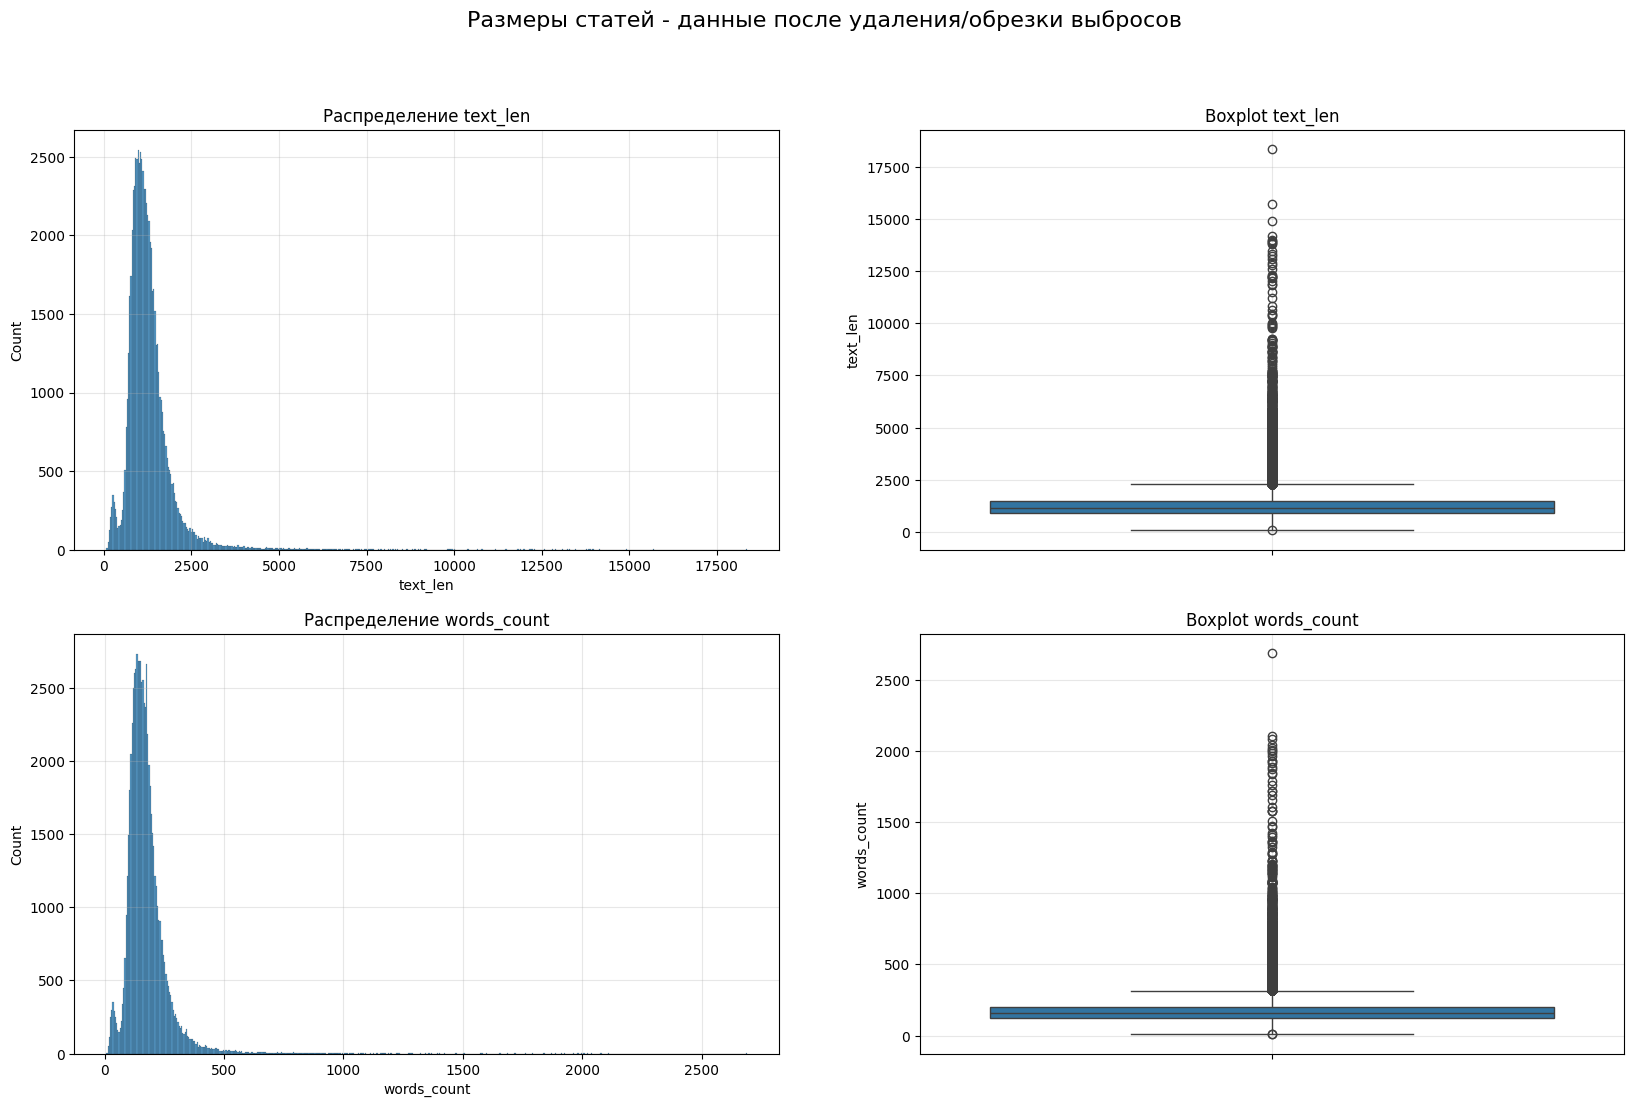

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12), dpi=100)
fig.suptitle("Размеры статей - данные после удаления/обрезки выбросов", fontsize=16)

plt.subplot(2, 2, 1)
sns.histplot(df["text_len"])
plt.title("Распределение text_len")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
sns.boxplot(y=df["text_len"])
plt.title("Boxplot text_len")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
sns.histplot(df["words_count"])
plt.title("Распределение words_count")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
sns.boxplot(y=df["words_count"])
plt.title("Boxplot words_count")
plt.grid(True, alpha=0.3)
plt.savefig(ARTIFACTS_PATH / "news_len_after_outlier_removing.png")
plt.show()

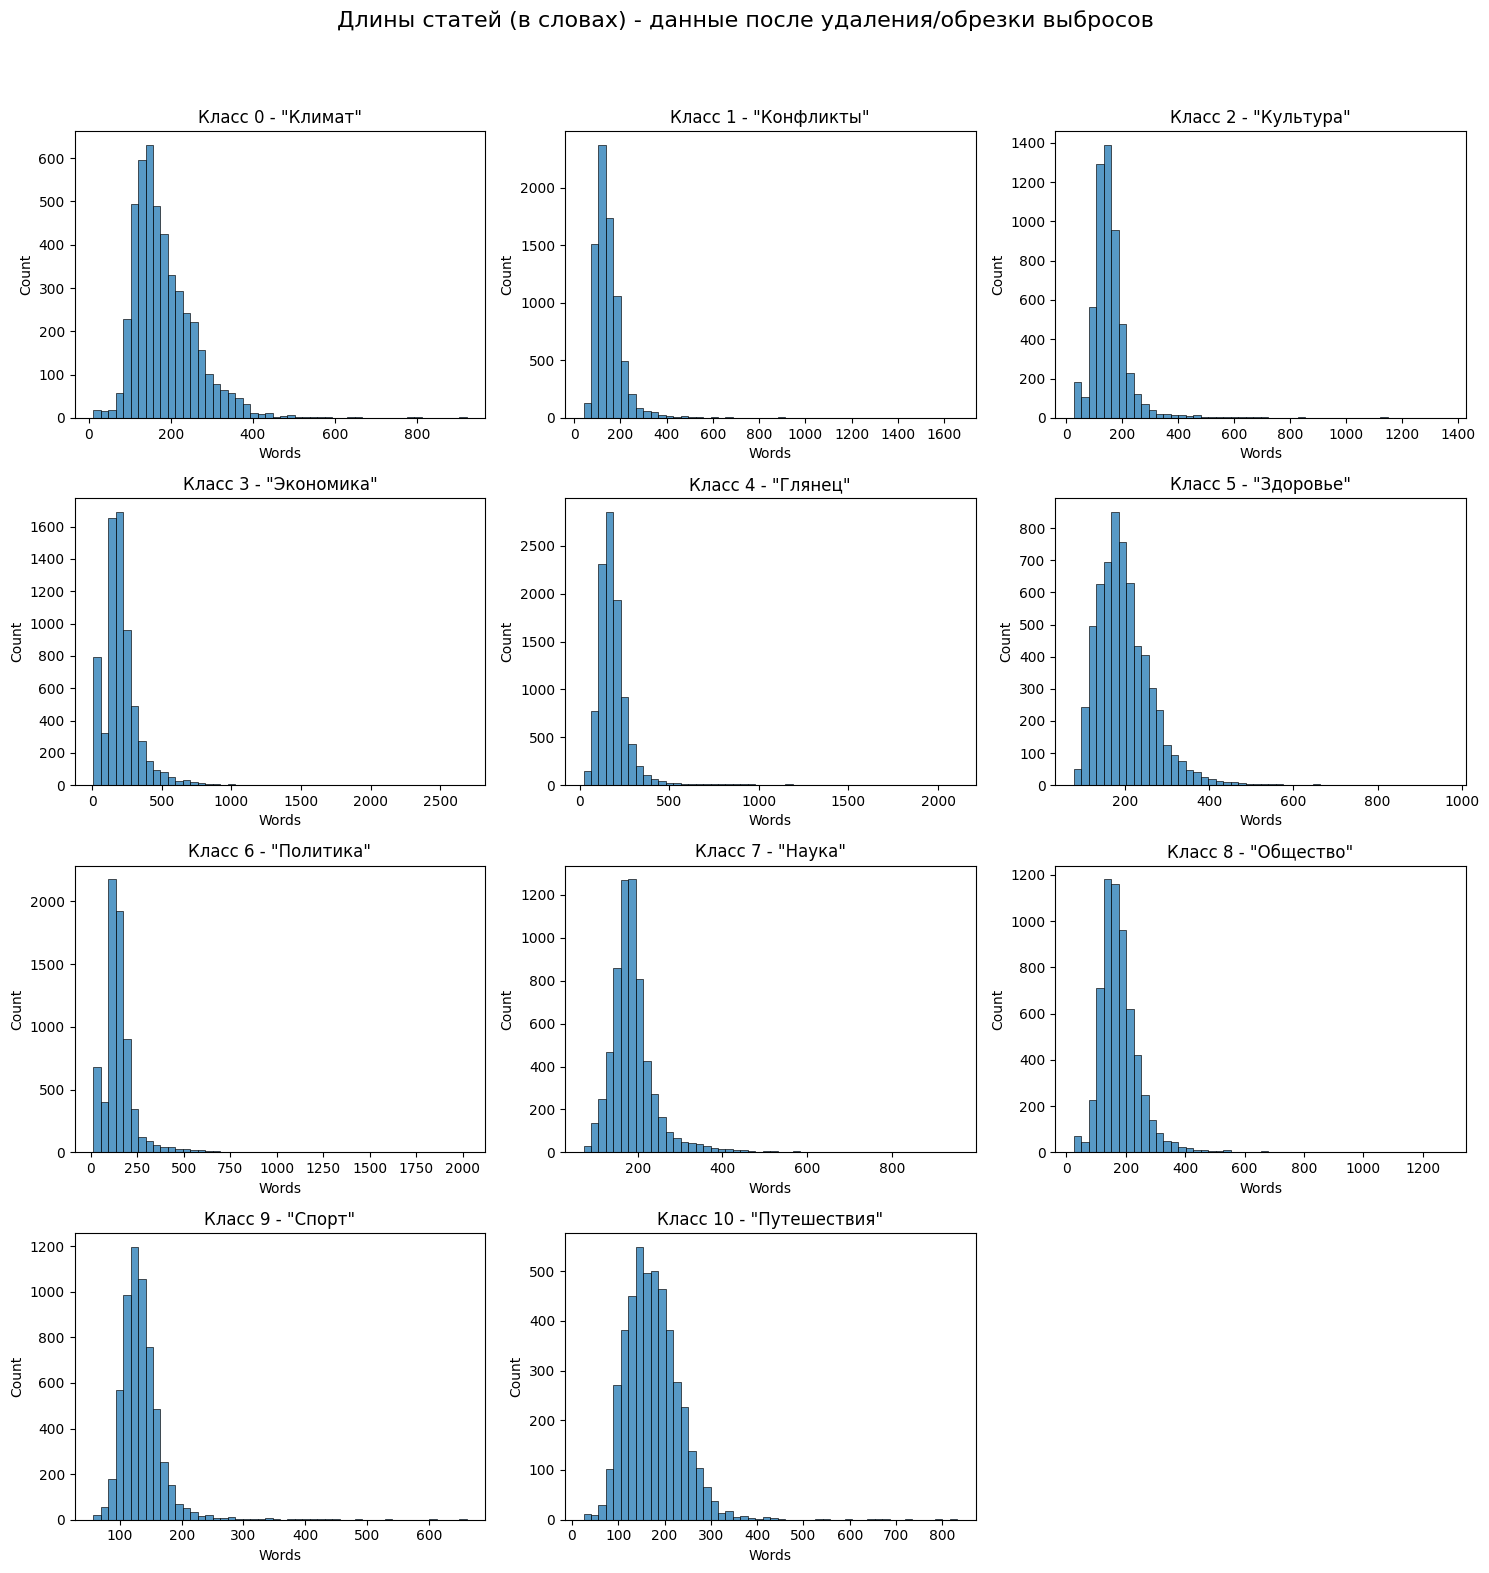

In [19]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
fig.suptitle("Длины статей (в словах) - данные после удаления/обрезки выбросов", fontsize=16)

axes = axes.flatten()

for ax, cls in zip(axes, classes):
    subset = df[df["labels"] == cls]
    sns.histplot(x=subset["words_count"], ax=ax, bins=50)
    ax.set_title(f"Класс {cls} - \"{russian_names[cls]}\"")
    ax.set_xlabel("Words")

for ax in axes[len(classes):]:
    fig.delaxes(ax)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(ARTIFACTS_PATH / "news_len_by_classes_after_outlier_removing.png")
plt.show()

In [20]:
df["category_name"].value_counts(normalize=True)

category_name
Глянец         0.141150
Конфликты      0.110039
Политика       0.097862
Экономика      0.094095
Наука          0.090243
Здоровье       0.087661
Общество       0.085757
Спорт          0.084346
Культура       0.078758
Климат         0.065679
Путешествия    0.064409
Name: proportion, dtype: float64

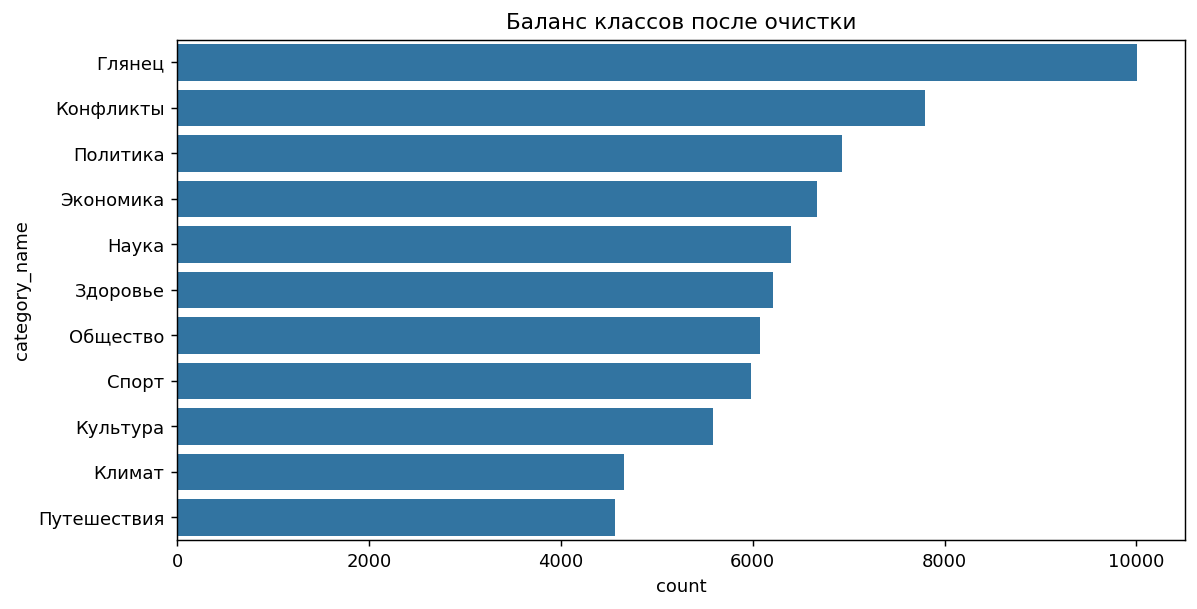

In [21]:
plt.figure(figsize=(10, 5), dpi=130)
plt.title("Баланс классов после очистки")
sns.countplot(
    data=df,
    y="category_name",
    order=df["category_name"].value_counts().index
)
plt.savefig(ARTIFACTS_PATH / "class_balance_after_prerpocessing.png")
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70875 entries, 0 to 70874
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   news           70875 non-null  object
 1   labels         70875 non-null  int32 
 2   category_name  70875 non-null  object
 3   text_len       70875 non-null  int64 
 4   words_count    70875 non-null  int64 
dtypes: int32(1), int64(2), object(2)
memory usage: 2.4+ MB


Датасет очищен! Далее рассмотрим какие топ-слова в новостных статьях. Функция `wc_plot` рисует Облако слов. 

In [23]:
def wc_plot(df: pd.DataFrame, target_col: str, top: int = 10) -> WordCloud:
    
    text = " ".join(df[target_col].dropna())
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=top,
        colormap="viridis",
        collocations=False,
        random_state=42
    ).generate(text)

    return wc


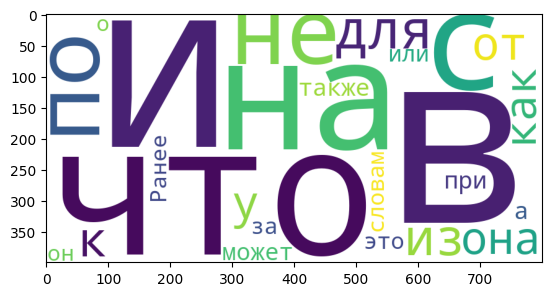

In [24]:
plt.imshow(wc_plot(df[df.labels == 5], "news", top=25))
plt.show()

Заметим, что среди топ-слов находиться множество стоп-слов - слов, не несущих смысловой нагрузки. Для дальнейших исследований (облако слов и TF-IDF-baselines) следует убрать их.

In [25]:
stop_words = {
    # -------------------------
    # МЕСТОИМЕНИЯ
    # -------------------------
    "я", "ты", "он", "она", "оно", "мы", "вы", "они",
    "меня", "тебя", "его", "её", "ее", "нас", "вас", "их",
    "мне", "тебе", "ему", "ей", "нам", "вам", "им",
    "мой", "твой", "свой", "наш", "ваш", "их",
    "себя", "себе", "сам", "сама", "само", "сами",
    "этот", "эта", "это", "эти", "тот", "та", "то", "те",
    "который", "которая", "которое", "которые",
    "какой", "какая", "какое", "какие",
    "весь", "вся", "всё", "все",
    "такой", "такая", "такое", "такие",
    "каждый", "каждая", "каждое", "каждые",
    "любой", "любая", "любое", "любые",
    "чей", "чья", "чьё", "чьи",
    "некий", "некая", "некое", "некие",
    "некоторый", "некоторая", "некоторое", "некоторые",
    "кто", "что", "кого", "чего", "кому", "чему", "кем", "чем",

    # -------------------------
    # ПРЕДЛОГИ
    # -------------------------
    "в", "во", "на", "по", "за", "у", "под", "над", "до",
    "из", "с", "со", "от", "для", "к", "ко", "перед",
    "про", "через", "между", "вокруг", "около", "возле",
    "при", "без", "ради", "спустя", "вдоль", "поперёк",
    "мимо", "из-за", "из-под", "ввиду", "вследствие",
    "вместо", "вне", "внутри", "среди",

    # -------------------------
    # СОЮЗЫ
    # -------------------------
    "и", "а", "но", "да", "или", "либо",
    "если", "когда", "пока", "что", "чтобы", "чтоб",
    "как", "будто", "словно", "также", "тоже",
    "однако", "причем", "притом", "зато",
    "потому", "поэтому", "тогда", "чем", "причём",

    # -------------------------
    # ЧАСТИЦЫ
    # -------------------------
    "бы", "б", "же", "ж", "ли", "ль",
    "ведь", "даже", "лишь", "только",
    "вот", "уж", "уже",
    "не", "ни", "то", "ну", "вон", "мол",

    # -------------------------
    # НАРЕЧИЯ
    # -------------------------
    "так", "тогда", "сейчас", "потом", "ранее", "позже",
    "здесь", "там", "туда", "сюда", "отсюда", "оттуда",
    "везде", "всюду", "нигде",
    "всегда", "иногда", "часто", "редко", "обычно",
    "ещё", "еще", "вновь", "опять", "снова",
    "сегодня", "вчера", "завтра", "теперь", "скоро",
    "более", "менее", "очень", "весьма",
    "довольно", "почти", "практически",
    "совсем", "вполне", "абсолютно",
    "самый", "самая", "самое", "самые",
    "больше", "меньше", "лучше", "хуже",
    "вместе", "отдельно", "рядом",
    "хорошо", "плохо", "быстро", "медленно",
    "особенно", "именно", "просто",

    # -------------------------
    # ВВОДНЫЕ СЛОВА
    # -------------------------
    "конечно", "возможно", "кажется", "видимо", "похоже",
    "вообще", "кстати", "например", "наконец",
    "значит", "следовательно", "итак", "таким", "образом",
    "вероятно", "очевидно", "безусловно", "несомненно",
    "действительно", "естественно", "разумеется",
    "пожалуй", "наверное", "видимо", "по-видимому",
    "впрочем", "правда", "кроме", "того",
    "во-первых", "во-вторых", "в-третьих",

    # -------------------------
    # ГЛАГОЛЫ-СВЯЗКИ / МОДАЛЬНЫЕ
    # -------------------------
    "быть", "был", "была", "было", "были", "будет", "будут",
    "есть", "являться", "является",
    "может", "могут", "мочь",
    "нужно", "надо", "должен", "должна", "должны",
    "стал", "стала", "стало", "стали",
    "имеется", "имеются", "имел", "имела", "имело", "имели",
    "хочет", "хотят", "хотели", "хотел", "хотела",
    "делает", "делают", "делал", "делала",
    "получил", "получила", "получили",

    # -------------------------
    # НОВОСТНОЙ ШУМ — ГЛАГОЛЫ РЕЧИ
    # -------------------------
    "сообщил", "сообщила", "сообщили", "сообщается",
    "сообщать", "сообщает", "сообщить",
    "заявил", "заявила", "заявили",
    "заявлять", "заявляет", "заявить",
    "отметил", "отметила", "отметили",
    "отмечать", "отмечает", "отметить",
    "добавил", "добавила", "добавили",
    "добавлять", "добавляет", "добавить",
    "рассказал", "рассказала", "рассказали",
    "рассказывать", "рассказывает", "рассказать",
    "пояснил", "пояснила",
    "пояснять", "поясняет", "пояснить",
    "уточнил", "уточнила",
    "уточнять", "уточняет", "уточнить",
    "подчеркнул", "подчеркнула",
    "подчеркивать", "подчеркивает", "подчеркнуть",
    "передал", "передала",
    "говорится", "отмечается",
    "говорить", "говорит", "сказал", "сказала", "сказали",
    "объяснил", "объяснила", "объяснили",
    "напомнил", "напомнила", "напомнили",
    "прокомментировал", "прокомментировала",
    "огласил", "огласила", "огласили",
    "обнародовал", "обнародовала",
    "поинформировал", "проинформировал",
    "поделился", "поделилась", "поделились",
    "выразил", "выразила",
    "высказался", "высказалась", "высказались",

    # -------------------------
    # КАНЦЕЛЯРИЗМЫ / ФОРМАЛЬНЫЙ ШУМ
    # -------------------------
    "данный", "данная", "данное", "данные",
    "соответствующий", "соответствующая",
    "вышеуказанный", "нижеследующий",
    "настоящий", "настоящая",
    "следующий", "следующая",
    "предыдущий", "предыдущая",
    "подобный", "подобная",
    "известно", "известный",
    "составляет", "осуществляет", "производится",
    "также", "кроме", "помимо", "включая",
    "включает", "содержит", "имеется",
    "являясь", "будучи",

    # -------------------------
    # ВРЕМЕННЫЕ / ОБЩИЕ СУЩЕСТВИТЕЛЬНЫЕ
    # -------------------------
    "год", "года", "лет", "году",
    "первый", "второй", "третий",
    "новый", "старый", "последний",
    "несколько", "многие", "некоторые",
    "часть", "части", "случай", "случае",
    "число", "числе", "числа",
    "раз", "раза", "время", "времени",

    # -------------------------
    # МЕДИА / ТЕХНИЧЕСКИЙ ШУМ
    # -------------------------
    "фото", "видео", "кадр", "издание", "источник",
    "сайт", "страница",
    "материал", "публикация",
    "лента", "новость", "новости",
    "риа", "тасс", "интерфакс", "газета",
    "ru", "com",
    "rt", "amp", "nbsp",

    # -------------------------
    # URL / HTML
    # -------------------------
    "http", "https", "www", "html", "php",

    # -------------------------
    # ВАЛЮТА / ЧИСЛА (новостной шум)
    # -------------------------
    "рубль", "рубля", "рублей",
    "доллар", "доллара", "долларов",
    "тысяча", "тысячи", "тысяч",
    "миллион", "миллиона", "миллионов",
    "миллиард", "миллиарда", "миллиардов",
}

Функция `nlp_preprocess` очищает тексты статей от стоп слов и леммитизирует их.

In [26]:
morph = MorphAnalyzer()

def nlp_preprocess(text):

    text = re.sub(r"[^\w\s]", " ", text.lower())
    words = [w for w in text.split() if len(w) > 2 and w not in stop_words]
    lemmas = []
    
    for w in words:
        try:
            normal_forms = morph.normal_forms(w)
            if normal_forms:
                lemma = normal_forms[0]
                if lemma not in stop_words and len(lemma) > 2:
                    lemmas.append(lemma)
        except:
            continue
    
    return " ".join(lemmas[:500])

In [27]:
nlp_preprocess(
    """
    Гостей ждут американские горки, оформленные в стиле нью-йоркских тоннелей. На них возможны перевороты и взлеты до 30 метров.
    Есть также гигантская качель-змея и аттракцион с самолетами, где можно почувствовать себя пилотом.
    Для самых маленьких работают детские зоны с каруселями. 
    После волны адреналина можно подкрепиться в пиццерии или кондитерской, отдохнуть на лавочках или погулять по магазину сувениров.
    """
)

'гость ждать американский горка оформить стиль нью йоркский тоннель возможный переворот взлёт метр гигантский качели змея аттракцион самолёт где можно почувствовать пилот маленький работать детский зона карусель после волна адреналин можно подкрепиться пиццерия кондитерский отдохнуть лавочка погулять магазин сувенир'

In [28]:
df["news_tfidf_ready"] = df["news"].apply(nlp_preprocess)

In [29]:
df.head()

,news,labels,category_name,text_len,words_count,news_tfidf_ready
0,"Российские пожарные спасли детеныша косули, по...",0,Климат,1240,185,российский пожарный спасти детёныш косуля попа...
1,Житель Сахалина заметил на острове орлана — кр...,0,Климат,858,129,житель сахалин заметить остров орлан крупный х...
2,Российские заводы начнут работать по-новому ра...,0,Климат,1117,140,российский завод начать работать спасение план...
3,Неравнодушные россияне спасли слепого и глухог...,0,Климат,999,156,неравнодушный россиянин спасти слепой глухой е...
4,Специалисты предупредили граждан Британии о во...,0,Климат,1914,256,специалист предупредить гражданин британия воз...


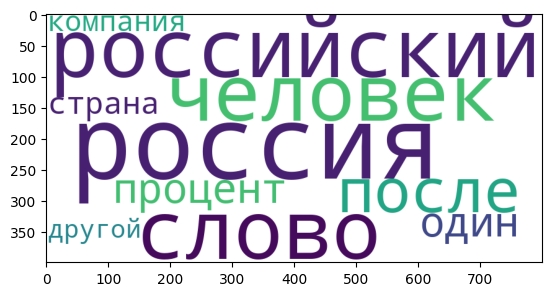

In [30]:
plt.imshow(wc_plot(df, "news_tfidf_ready"))
plt.show()

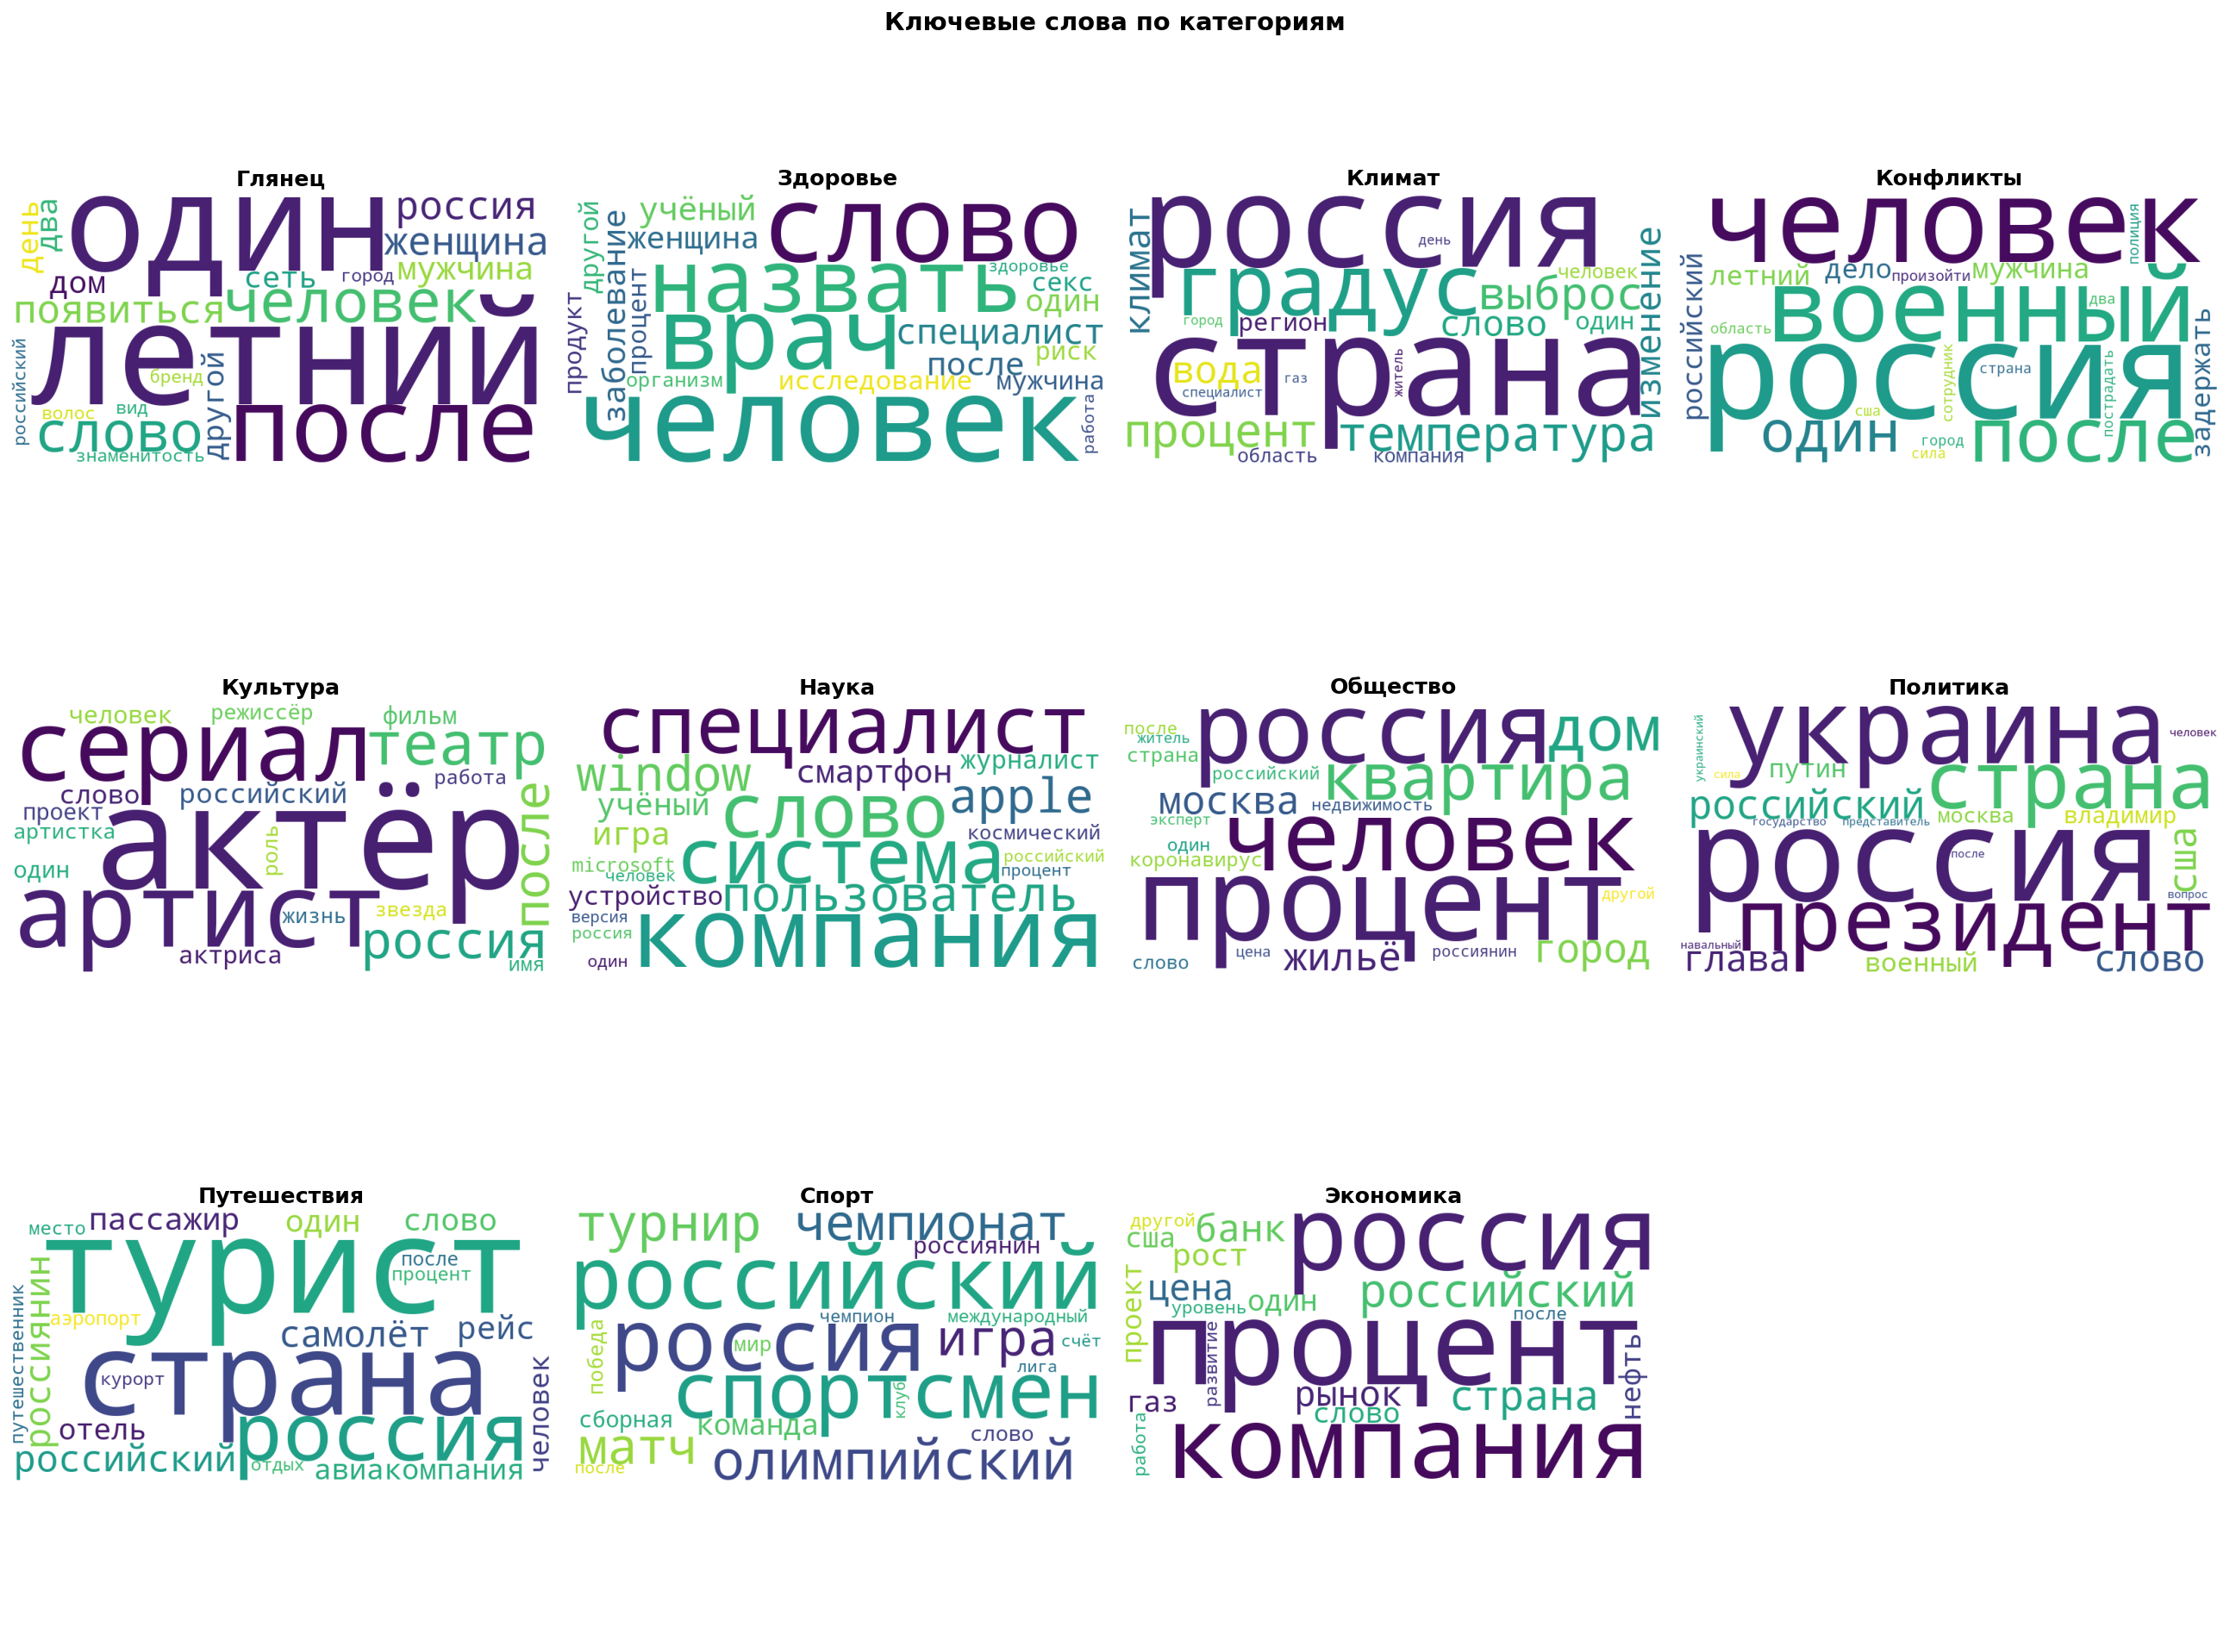

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15), dpi=130)
axes = axes.flatten()

for idx, cat in enumerate(sorted(russian_names.values())):
    wc = wc_plot(df[df.category_name == cat], "news_tfidf_ready", top=20)
    axes[idx].imshow(wc)
    axes[idx].axis("off")
    axes[idx].set_title(cat, fontsize=14, fontweight="bold")

axes[11].axis("off")
plt.suptitle("Ключевые слова по категориям", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "keywords_by_classes.png")
plt.show()

In [32]:
df.to_parquet(PREPROCESSED_DATA_PATH / "clean_data.parquet")